# 준비준비

In [1]:
## 1번 실행 -> 런타임 다시 시작 -> 2번 실행 -> 3번 실행

## 1번

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 49 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (21.3 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 123630 files and direc

In [1]:
## 2번

import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')

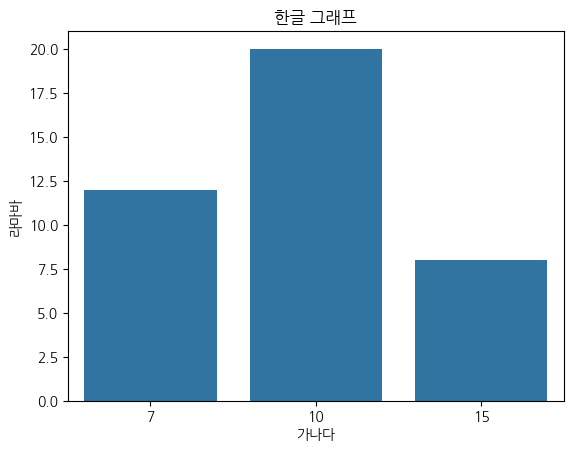

In [2]:
## 3번

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 나눔고딕 폰트 경로 설정
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()
plt.rc('font', family=font_name)

# 그래프 그리기 예시
data = {'가나다': [10, 15, 7], '라마바': [20, 8, 12]}
df = pd.DataFrame(data)
sns.barplot(data=df, x='가나다', y='라마바')
plt.title('한글 그래프')
plt.show()


# 시작

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
import os
import pandas as pd

# 파일 경로
train_file = '/content/drive/MyDrive/IDS/amaxon reviews 2023/Transnet/T2/train.csv'
valid_file = '/content/drive/MyDrive/IDS/amaxon reviews 2023/Transnet/T2/valid.csv'
test_file = '/content/drive/MyDrive/IDS/amaxon reviews 2023/Transnet/T2/test.csv'

# 파일 존재 확인
for file_path in [train_file, valid_file, test_file]:
    if os.path.exists(file_path):
        print(f"{file_path} exists.")
    else:
        print(f"{file_path} is missing!")

# 데이터 내용 확인
for file_path in [train_file, valid_file, test_file]:
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, header=None, names=['userID', 'itemID', 'review', 'rating'])
        print(f"\nContents of {file_path}:")
        print(df.head())


/content/drive/MyDrive/IDS/amaxon reviews 2023/Transnet/T2/train.csv exists.
/content/drive/MyDrive/IDS/amaxon reviews 2023/Transnet/T2/valid.csv exists.
/content/drive/MyDrive/IDS/amaxon reviews 2023/Transnet/T2/test.csv exists.

Contents of /content/drive/MyDrive/IDS/amaxon reviews 2023/Transnet/T2/train.csv:
                         userID      itemID  \
0  AFRMDWBD4RXSHKFZUOH6FGVP5I6Q  B07KJJ2DSH   
1  AENNGBGNPATANRDSKCSL5HHBGO4A  B07MGJZ2MH   
2  AG2YFAVEZSNFDWKJGHKCYEHM376A  B08D6W9F21   
3  AGUFZQ2FSNOAEQ3FOQ4PI5G2FCRQ  B08KWLQD46   
4  AHPSOZJQRM54EEZSHNKW63Q22RYA  B0933F8BYP   

                                              review  rating  
0  thoroughly enjoyed month craft project far not...       5  
1  like trying different flavors snacks might lik...       5  
2                 love shirts subscription going get       5  
3  unoriginal variation style cheap projects easi...       3  
4  well made high quality vibrant colors fits wel...       5  

Contents of /content/driv

config

In [20]:
# Config 클래스 정의
class Config:
    def __init__(self):
        self.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        self.train_epochs = 15
        self.batch_size = 128
        self.learning_rate = 0.002
        self.l2_regularization = 1e-6
        self.learning_rate_decay = 0.99
        self.train_file = '/content/drive/MyDrive/IDS/amaxon reviews 2023/Transnet/T2/train.csv'
        self.valid_file = '/content/drive/MyDrive/IDS/amaxon reviews 2023/Transnet/T2/valid.csv'
        self.test_file = '/content/drive/MyDrive/IDS/amaxon reviews 2023/Transnet/T2/test.csv'
        self.model_file = '/content/drive/MyDrive/IDS/amaxon reviews 2023/Transnet/T2/best_model.pt'
        self.extension = False
        self.user_count = 15225
        self.item_count = 641
        self.review_count = 10
        self.review_length = 80
        self.lowest_review_count = 1 ## orignal 2
        self.PAD_WORD = '<UNK>'
        self.kernel_count = 100
        self.kernel_size = 3
        self.dropout_prob = 0.5
        self.cnn_out_dim = 50

utils

In [21]:
import time
import pandas as pd
import torch
from torch.nn import functional as F
from torch.utils.data import Dataset


def date(f='%Y-%m-%d %H:%M:%S'):
    return time.strftime(f, time.localtime())


def calculate_mse(model, dataloader, device):
    mse, sample_count = 0, 0
    with torch.no_grad():
        for batch in dataloader:
            user_reviews, item_reviews, reviews, ratings, user_ids, item_ids = [x.to(device) for x in batch]
            latent, predict = model(user_reviews, item_reviews, user_ids, item_ids)
            mse += F.mse_loss(predict, ratings, reduction='sum').item()
            sample_count += len(ratings)
    return mse / sample_count  # mse of dataloader


class TransNetsDataset(Dataset):
    def __init__(self, data_path, word_dict, config):
        self.word_dict = word_dict
        self.r_count = config.review_count
        self.r_length = config.review_length
        self.lowest_r_count = config.lowest_review_count
        self.PAD_WORD_idx = word_dict[config.PAD_WORD]

        # 데이터 읽기
        df = pd.read_csv(data_path, header=None, names=['userID', 'itemID', 'review', 'rating'])

        # userID와 itemID를 숫자로 변환
        df['userID'] = df['userID'].astype('category').cat.codes
        df['itemID'] = df['itemID'].astype('category').cat.codes

        # 리뷰 데이터를 ID로 변환
        df['review'] = df['review'].apply(self._review2id)
        self.null_idx = set()

        # 사용자 및 아이템 리뷰 생성
        user_reviews = self._get_reviews(df)
        item_reviews = self._get_reviews(df, 'itemID', 'userID')

        # 리뷰, 평점, 사용자 및 아이템 ID를 텐서로 변환
        reviews = [self._adjust_review_list([x], 1, self.r_length) for x in df['review']]
        reviews = torch.LongTensor(reviews).view(-1, self.r_length)
        rating = torch.Tensor(df['rating'].to_list()).view(-1, 1)
        user_ids = torch.LongTensor(df['userID'].to_list()).view(-1, 1)
        item_ids = torch.LongTensor(df['itemID'].to_list()).view(-1, 1)

        # 유효하지 않은 데이터 제거 부분 제거
        self.user_reviews = user_reviews
        self.item_reviews = item_reviews
        self.reviews = reviews
        self.rating = rating
        self.user_ids = user_ids
        self.item_ids = item_ids

        ## Orignal
        # 유효하지 않은 데이터 제거
        #self.user_reviews = user_reviews[[idx for idx in range(user_reviews.shape[0]) if idx not in self.null_idx]]
        #self.item_reviews = item_reviews[[idx for idx in range(item_reviews.shape[0]) if idx not in self.null_idx]]
        #self.reviews = reviews[[idx for idx in range(reviews.shape[0]) if idx not in self.null_idx]]
        #self.rating = rating[[idx for idx in range(rating.shape[0]) if idx not in self.null_idx]]
        #self.user_ids = user_ids[[idx for idx in range(user_ids.shape[0]) if idx not in self.null_idx]]
        #self.item_ids = item_ids[[idx for idx in range(item_ids.shape[0]) if idx not in self.null_idx]]



    def __getitem__(self, idx):
        return self.user_reviews[idx], self.item_reviews[idx], self.reviews[idx], self.rating[idx],\
                self.user_ids[idx], self.item_ids[idx]

    def __len__(self):
        return self.rating.shape[0]

    def _get_reviews(self, df, lead='userID', costar='itemID'):
        reviews_by_lead = dict(list(df[[costar, 'review']].groupby(df[lead])))
        lead_reviews = []
        for idx, (lead_id, costar_id) in enumerate(zip(df[lead], df[costar])):
            df_data = reviews_by_lead[lead_id]
            reviews = df_data['review'][df_data[costar] != costar_id].to_list()
        # 필터링 조건 제거
            reviews = self._adjust_review_list(reviews, self.r_count, self.r_length)
            lead_reviews.append(reviews)
        return torch.LongTensor(lead_reviews)


    ## Orignal
    #def _get_reviews(self, df, lead='userID', costar='itemID'):
        # For every sample(user,item), gather reviews for user/item.
    #    reviews_by_lead = dict(list(df[[costar, 'review']].groupby(df[lead])))  # Information for every user/item
    #    lead_reviews = []
    #    for idx, (lead_id, costar_id) in enumerate(zip(df[lead], df[costar])):
    #        df_data = reviews_by_lead[lead_id]  # get information of lead, return DataFrame.
    #        reviews = df_data['review'][df_data[costar] != costar_id].to_list()  # get reviews without review u for i.
    #        if len(reviews) < self.lowest_r_count:
    #            self.null_idx.add(idx)
    #        reviews = self._adjust_review_list(reviews, self.r_count, self.r_length)
    #        lead_reviews.append(reviews)
    #    return torch.LongTensor(lead_reviews)

    def _adjust_review_list(self, reviews, r_count, r_length):
        reviews = reviews[:r_count] + [[self.PAD_WORD_idx] * r_length] * (r_count - len(reviews))  # Certain count.
        reviews = [r[:r_length] + [0] * (r_length - len(r)) for r in reviews]  # Certain length of review.
        return reviews

    def _review2id(self, review):
        if not isinstance(review, str):  # 리뷰가 문자열인지 확인
            return []  # 문자열이 아니면 빈 리스트 반환
        return [self.word_dict.get(word, self.PAD_WORD_idx) for word in review.split()]



def _review2id(self, review):  # Split a sentence into words, and map each word to a unique number by dict.
    if not isinstance(review, str):
        return []
    wids = []
    for word in review.split():
        if word in self.word_dict:
            wids.append(self.word_dict[word])  # word to unique number by dict.
        else:
            wids.append(self.PAD_WORD_idx)
    return wids


main

In [28]:
# 모델 정의
import torch
from torch import nn

class CNN(nn.Module):
    def __init__(self, config, word_dim, review_count=1):
        super(CNN, self).__init__()
        self.kernel_count = config.kernel_count
        self.review_count = review_count

        self.conv = nn.Sequential(
            nn.Conv1d(
                in_channels=word_dim,
                out_channels=config.kernel_count,
                kernel_size=config.kernel_size,
                padding=(config.kernel_size - 1) // 2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1, config.review_length)),
        )

        self.linear = nn.Sequential(
            nn.Linear(config.kernel_count * self.review_count, config.cnn_out_dim),
            nn.Tanh(),
        )

    def forward(self, vec):
        latent = self.conv(vec.permute(0, 2, 1))
        latent = latent.view(-1, self.kernel_count * self.review_count)
        latent = self.linear(latent)
        return latent


class FactorizationMachine(nn.Module):
    def __init__(self, in_dim, k):
        super(FactorizationMachine, self).__init__()
        self.v = nn.Parameter(torch.full([in_dim, k], 0.001))
        self.linear = nn.Linear(in_dim, 1)
        self.linear.weight.data.normal_(mean=0, std=0.001)

    def forward(self, x):
        linear_part = self.linear(x)
        inter_part1 = torch.mm(x, self.v)
        inter_part2 = torch.mm(x ** 2, self.v ** 2)
        pair_interactions = torch.sum(inter_part1 ** 2 - inter_part2, dim=1)
        output = linear_part.t() + 0.5 * pair_interactions
        return output.view(-1, 1)


class SourceNet(nn.Module):
    def __init__(self, config, word_emb, extend_model=False):
        super(SourceNet, self).__init__()
        self.extend_model = extend_model
        self.embedding = nn.Embedding.from_pretrained(torch.Tensor(word_emb))
        self.cnn_u = CNN(config, word_dim=self.embedding.embedding_dim, review_count=config.review_count)
        self.cnn_i = CNN(config, word_dim=self.embedding.embedding_dim, review_count=config.review_count)
        self.transform = nn.Sequential(
            nn.Linear(config.cnn_out_dim * 2, config.cnn_out_dim),
            nn.Tanh(),
            nn.Linear(config.cnn_out_dim, config.cnn_out_dim),
            nn.Tanh(),
            nn.Dropout(p=config.dropout_prob)
        )

        if self.extend_model:
            self.emb_u = nn.Embedding(config.user_count, config.cnn_out_dim, padding_idx=0)
            self.emb_i = nn.Embedding(config.item_count, config.cnn_out_dim, padding_idx=0)
            self.fm = FactorizationMachine(in_dim=config.cnn_out_dim * 3, k=8)
        else:
            self.fm = FactorizationMachine(in_dim=config.cnn_out_dim, k=8)

    def forward(self, user_reviews, item_reviews, user_ids, item_ids):
        u_vec = self.embedding(user_reviews.view(-1, user_reviews.shape[-1]))
        i_vec = self.embedding(item_reviews.view(-1, item_reviews.shape[-1]))

        user_latent = self.cnn_u(u_vec)
        item_latent = self.cnn_i(i_vec)

        concat_latent = torch.cat((user_latent, item_latent), dim=1)
        trans_latent = self.transform(concat_latent)

        if self.extend_model:
            omega_u = self.emb_u(user_ids.view(-1))
            omega_i = self.emb_i(item_ids.view(-1))
            latent = torch.cat([omega_u, omega_i, trans_latent.detach()], dim=1)
            prediction = self.fm(latent)
        else:
            prediction = self.fm(trans_latent.detach())
        return trans_latent, prediction

    def trans_param(self):
        return self.transform.parameters()



class TargetNet(nn.Module):
    def __init__(self, config, word_emb):
        super(TargetNet, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(torch.Tensor(word_emb))
        self.cnn = CNN(config, word_dim=self.embedding.embedding_dim, review_count=1)
        self.fm = nn.Sequential(
            nn.Dropout(config.dropout_prob),
            FactorizationMachine(in_dim=config.cnn_out_dim, k=8)
        )

    def forward(self, reviews):
        vec = self.embedding(reviews)
        cnn_latent = self.cnn(vec)
        prediction = self.fm(cnn_latent)
        return cnn_latent, prediction


# 학습 및 테스트 함수
def train(train_dataloader, valid_dataloader, model_S, model_T, config, model_path):
    print(f'{date()}## Start the training!')
    train_mse = calculate_mse(model_S, train_dataloader, config.device)
    valid_mse = calculate_mse(model_S, valid_dataloader, config.device)
    print(f'{date()}#### Initial train mse {train_mse:.6f}, validation mse {valid_mse:.6f}')
    start_time = time.perf_counter()

    opt_S = torch.optim.Adam(model_S.parameters(), config.learning_rate, weight_decay=config.l2_regularization)
    opt_trans = torch.optim.Adam(model_S.trans_param(), config.learning_rate, weight_decay=config.l2_regularization)
    opt_T = torch.optim.Adam(model_T.parameters(), config.learning_rate, weight_decay=config.l2_regularization)
    lr_sch_S = torch.optim.lr_scheduler.ExponentialLR(opt_S, config.learning_rate_decay)
    lr_sch_trans = torch.optim.lr_scheduler.ExponentialLR(opt_trans, config.learning_rate_decay)
    lr_sch_T = torch.optim.lr_scheduler.ExponentialLR(opt_T, config.learning_rate_decay)

    best_loss, batch_step = 100, 0
    model_T.train()
    for epoch in range(config.train_epochs):
        model_S.train()
        total_loss, total_samples = 0, 0
        for batch in train_dataloader:
            user_reviews, item_reviews, reviews, ratings, user_ids, item_ids = [x.to(config.device) for x in batch]
            latent_T, pred_T = model_T(reviews)
            loss_T = F.l1_loss(pred_T, ratings)
            opt_T.zero_grad()
            loss_T.backward()

            latent_S, pred_S = model_S(user_reviews, item_reviews, user_ids, item_ids)
            loss_trans = F.mse_loss(latent_S, latent_T.detach())
            opt_trans.zero_grad()
            loss_trans.backward()

            loss_S = F.l1_loss(pred_S, ratings, reduction='sum')
            opt_S.zero_grad()
            loss_S.backward()

            opt_T.step()
            opt_trans.step()
            opt_S.step()

            batch_step += 1
            total_loss += loss_S.item()
            total_samples += len(pred_S)

            if batch_step % 500 == 0:
                model_S.eval()
                valid_mse = calculate_mse(model_S, valid_dataloader, config.device)
                if best_loss > valid_mse:
                    best_loss = valid_mse
                    torch.save(model_S, model_path)
                print(f"{date()}###### Step {batch_step:3d}; validation mse {valid_mse:.6f}")
                model_S.train()

        lr_sch_S.step()
        lr_sch_trans.step()
        lr_sch_T.step()
        valid_mse = calculate_mse(model_S, valid_dataloader, config.device)
        if best_loss > valid_mse:
            best_loss = valid_mse
            torch.save(model_S, model_path)
        print(f"{date()}#### Epoch {epoch:3d}; train mse {total_loss/total_samples:.6f}; validation mse {valid_mse:.6f}")

    print(f'{date()}## End of training!')

def test(dataloader, best_model, config):
    print(f'{date()}## Start the testing!')
    test_loss = calculate_mse(best_model, dataloader, config.device)
    print(f"{date()}## Test end, test mse is {test_loss:.6f}")


In [23]:
import torch
import inspect
import os
import pickle
import pandas as pd
import time
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

In [24]:
from google.colab import drive
drive.mount('/content/drive')

# 파일 경로 확인
assert os.path.exists('/content/drive/MyDrive/IDS/amaxon reviews 2023/Transnet/word_emb.pkl'), "word_emb.pkl not found"
assert os.path.exists('/content/drive/MyDrive/IDS/amaxon reviews 2023/Transnet/dict.pkl'), "dict.pkl not found"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
# 실행부
if __name__ == '__main__':
    config = Config()
    print(config)

    # 파일 경로 확인
    assert os.path.exists(config.train_file), "Train file not found"
    assert os.path.exists(config.valid_file), "Valid file not found"
    assert os.path.exists(config.test_file), "Test file not found"

    print("## Load word2vec and data...")
    word_emb = pickle.load(open('/content/drive/MyDrive/IDS/amaxon reviews 2023/Transnet/word_emb.pkl', 'rb'), encoding='iso-8859-1')
    word_dict = pickle.load(open('/content/drive/MyDrive/IDS/amaxon reviews 2023/Transnet/dict.pkl', 'rb'), encoding='iso-8859-1')

    # 데이터셋 생성
    train_dataset = TransNetsDataset(config.train_file, word_dict, config)
    valid_dataset = TransNetsDataset(config.valid_file, word_dict, config)
    test_dataset = TransNetsDataset(config.test_file, word_dict, config)

    # 데이터셋 크기 출력
    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Valid dataset size: {len(valid_dataset)}")
    print(f"Test dataset size: {len(test_dataset)}")

    # 데이터 로더 생성
    train_dlr = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
    valid_dlr = DataLoader(valid_dataset, batch_size=config.batch_size, shuffle=True)
    test_dlr = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=True)

    source_model = SourceNet(config, word_emb, extend_model=config.extension).to(config.device)
    target_model = TargetNet(config, word_emb).to(config.device)

    os.makedirs(os.path.dirname(config.model_file), exist_ok=True)

    train(train_dlr, valid_dlr, source_model, target_model, config, config.model_file)
    test(test_dlr, torch.load(config.model_file), config)


## Load word2vec and data...
Train dataset size: 12795
Valid dataset size: 1599
Test dataset size: 1600
2024-11-25 14:39:10## Start the training!
2024-11-25 14:39:11#### Initial train mse 16.232875, validation mse 16.141314
2024-11-25 14:39:12#### Epoch   0; train mse 2.591454; validation mse 3.677689
2024-11-25 14:39:13#### Epoch   1; train mse 1.573066; validation mse 3.526490
2024-11-25 14:39:14#### Epoch   2; train mse 1.540775; validation mse 3.478605
2024-11-25 14:39:15#### Epoch   3; train mse 1.518005; validation mse 3.534864
2024-11-25 14:39:16###### Step 500; validation mse 2.507793
2024-11-25 14:39:16#### Epoch   4; train mse 1.492070; validation mse 3.354705
2024-11-25 14:39:18#### Epoch   5; train mse 1.480012; validation mse 3.231388
2024-11-25 14:39:19#### Epoch   6; train mse 1.469800; validation mse 3.159934
2024-11-25 14:39:20#### Epoch   7; train mse 1.439435; validation mse 3.252150
2024-11-25 14:39:21#### Epoch   8; train mse 1.417379; validation mse 3.161496
2024-

<ipython-input-30-09779ddf4eda>:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test(test_dlr, torch.load(config.model_file), config)
